# 04 — XGBoost Tuning, SHAP Explainability & Business Threshold

Three things a fraud model needs before it ships:
1. **Tuning** — a light `RandomizedSearchCV` (PR-AUC scored) to confirm the config is sound.
2. **Explainability** — SHAP, so the model is auditable, not a black box.
3. **A business-driven threshold** — tuned to a recall target ("catch 90% of fraud"), then read off the precision / review-cost it implies.

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
MODELS = ROOT / "models"; MODELS.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110

import features as F
X_train, y_train, X_test, y_test = F.load_train_test()
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("train:", X_train.shape, "| test:", X_test.shape, "| spw:", round(scale_pos_weight, 1))

train: (1296675, 23) | test: (555719, 23) | spw: 171.8


## 1. Light hyperparameter search

RandomizedSearchCV (8 candidates × 3-fold) scored on **average precision (PR-AUC)**, run on a 300k stratified subsample for speed. The best config is then refit on the **full** training set.

In [2]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedShuffleSplit, train_test_split
from xgboost import XGBClassifier

Xs, _, ys, _ = train_test_split(X_train, y_train, train_size=300_000,
                                stratify=y_train, random_state=42)
print("search subsample:", Xs.shape, "| fraud:", int(ys.sum()))

param_dist = {
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.03, 0.05, 0.1, 0.2],
    "n_estimators": [200, 400, 600],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 1, 5],
}
base = XGBClassifier(scale_pos_weight=scale_pos_weight, tree_method="hist",
                     eval_metric="aucpr", n_jobs=-1, random_state=42)
search = RandomizedSearchCV(base, param_dist, n_iter=8, scoring="average_precision",
                            cv=StratifiedShuffleSplit(n_splits=3, test_size=0.25, random_state=42),
                            n_jobs=1, random_state=42, verbose=0)
search.fit(Xs, ys)
print("best CV PR-AUC:", round(search.best_score_, 4))
print("best params:", search.best_params_)

search subsample: (300000, 23) | fraud: 1737


best CV PR-AUC: 0.9015
best params: {'subsample': 0.7, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 1.0}


In [3]:
from sklearn.metrics import average_precision_score, roc_auc_score

best = XGBClassifier(**search.best_params_, scale_pos_weight=scale_pos_weight,
                     tree_method="hist", eval_metric="aucpr", n_jobs=-1, random_state=42)
best.fit(X_train, y_train)
proba = best.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, proba)
print(f"Tuned XGBoost (full-train refit) -> test PR-AUC = {pr_auc:.4f}, ROC-AUC = {roc_auc_score(y_test, proba):.4f}")

import joblib
joblib.dump(best, MODELS / "xgboost_tuned.joblib")
print("saved models/xgboost_tuned.joblib")

Tuned XGBoost (full-train refit) -> test PR-AUC = 0.8800, ROC-AUC = 0.9978
saved models/xgboost_tuned.joblib


## 2. SHAP explainability

**Global** (which features drive fraud overall) and **local** (why one specific transaction was flagged).

In [4]:
import shap

# Sample for speed; keep it a DataFrame so feature names survive.
Xs_shap = X_test.sample(3000, random_state=42)
explainer = shap.TreeExplainer(best)
sv = explainer(Xs_shap)
print("SHAP values:", sv.values.shape)

C:\Users\triaz\miniconda3_New\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values: (3000, 23)


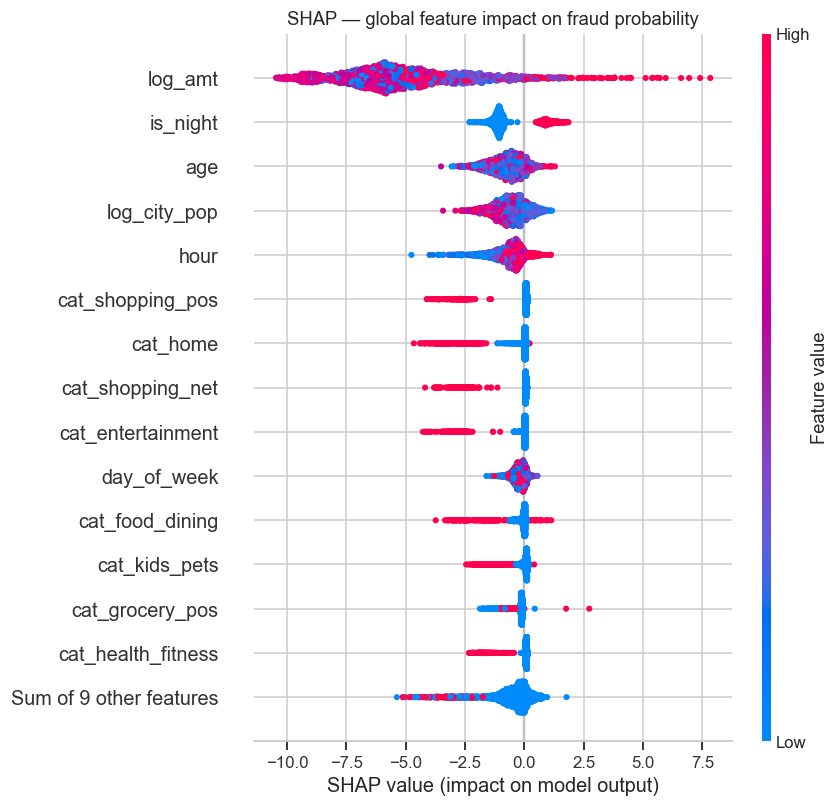

In [5]:
plt.figure()
shap.plots.beeswarm(sv, max_display=15, show=False)
plt.title("SHAP — global feature impact on fraud probability")
plt.tight_layout(); plt.savefig(FIG / "09_shap_beeswarm.png", bbox_inches="tight"); plt.show()

Explaining row 485: actual=1, fraud prob=1.000


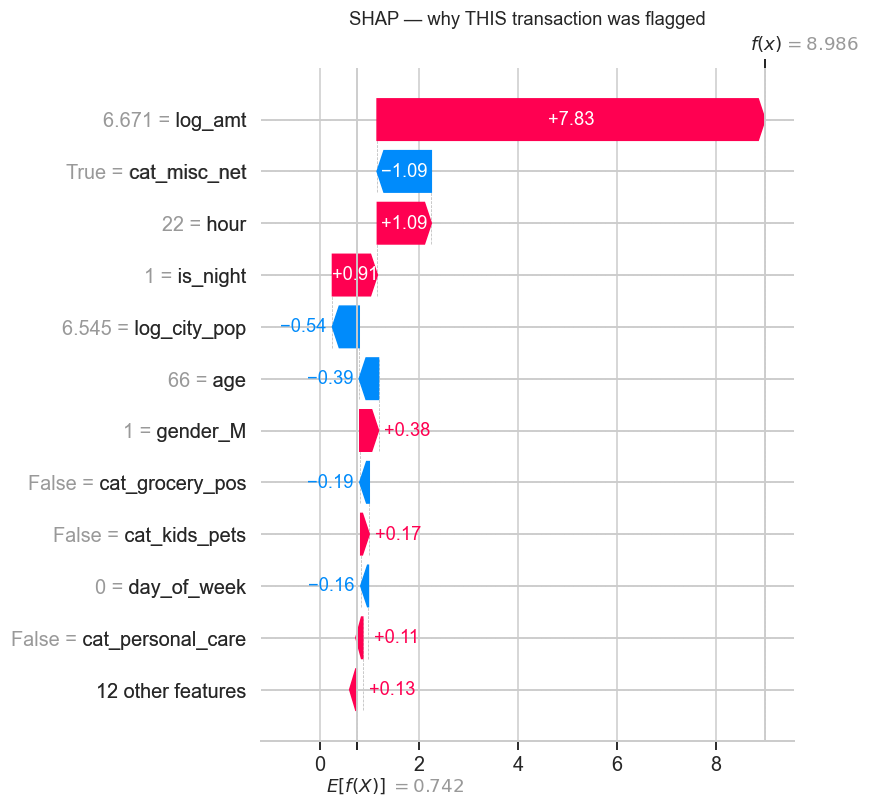

In [6]:
# Local explanation: pick a transaction the model correctly flagged as fraud.
proba_shap = best.predict_proba(Xs_shap)[:, 1]
y_shap = y_test.loc[Xs_shap.index]
tp_mask = (y_shap.values == 1) & (proba_shap >= 0.5)
idx = int(np.argmax(tp_mask)) if tp_mask.any() else int(np.argmax(proba_shap))
print(f"Explaining row {idx}: actual={int(y_shap.values[idx])}, fraud prob={proba_shap[idx]:.3f}")

plt.figure()
shap.plots.waterfall(sv[idx], max_display=12, show=False)
plt.title("SHAP — why THIS transaction was flagged")
plt.tight_layout(); plt.savefig(FIG / "10_shap_waterfall.png", bbox_inches="tight"); plt.show()

## 3. Business-driven threshold — target 90% recall

The bank's policy: **catch at least 90% of fraud**. We find the highest-precision threshold that meets that recall, then read off the operational trade-off.

In [7]:
from sklearn.metrics import precision_recall_curve, confusion_matrix

TARGET_RECALL = 0.90
prec, rec, thr = precision_recall_curve(y_test, proba)
# precision_recall_curve returns one more point than thresholds; align.
ok = rec[:-1] >= TARGET_RECALL
i = np.where(ok)[0][np.argmax(prec[:-1][ok])]
chosen_thr = float(thr[i])
print(f"Threshold for >= {TARGET_RECALL:.0%} recall: {chosen_thr:.4f}")
print(f"  -> recall={rec[i]:.3f}, precision={prec[i]:.3f}")

pred = (proba >= chosen_thr).astype(int)
cm = confusion_matrix(y_test, pred)
tn, fp, fn, tp = cm.ravel()
print(pd.DataFrame(cm, index=["actual_legit", "actual_fraud"], columns=["pred_legit", "pred_fraud"]))

json.dump({"threshold": chosen_thr, "target_recall": TARGET_RECALL,
          "recall": float(rec[i]), "precision": float(prec[i]), "pr_auc": float(pr_auc)},
          open(MODELS / "threshold.json", "w"), indent=2)
print("\nsaved models/threshold.json")

Threshold for >= 90% recall: 0.7999
  -> recall=0.900, precision=0.503
              pred_legit  pred_fraud
actual_legit      551664        1910
actual_fraud         214        1931

saved models/threshold.json


In [8]:
# Business impact translation
total_fraud = int(tp + fn)
print("=== BUSINESS IMPACT @ chosen threshold ===")
print(f"Frauds in test period      : {total_fraud:,}")
print(f"Caught (true positives)    : {tp:,}  ({tp/total_fraud:.1%})")
print(f"Missed (false negatives)   : {fn:,}  ({fn/total_fraud:.1%})")
print(f"False alarms (to review)   : {fp:,}  out of {tn+fp:,} legit ({fp/(tn+fp):.2%})")
print(f"Of everything flagged, {tp/(tp+fp):.1%} is real fraud (precision).")

# vs the LogReg baseline recall (from notebook 03)
baseline_recall = 0.5841
print(f"\nIf 10,000 frauds occurred:")
print(f"  baseline LogReg (recall {baseline_recall:.0%}) catches ~{int(10000*baseline_recall):,}, misses ~{int(10000*(1-baseline_recall)):,}")
print(f"  tuned XGBoost  (recall {rec[i]:.0%}) catches ~{int(10000*rec[i]):,}, misses ~{int(10000*(1-rec[i])):,}")

=== BUSINESS IMPACT @ chosen threshold ===
Frauds in test period      : 2,145
Caught (true positives)    : 1,931  (90.0%)
Missed (false negatives)   : 214  (10.0%)
False alarms (to review)   : 1,910  out of 553,574 legit (0.35%)
Of everything flagged, 50.3% is real fraud (precision).

If 10,000 frauds occurred:
  baseline LogReg (recall 58%) catches ~5,840, misses ~4,159
  tuned XGBoost  (recall 90%) catches ~9,002, misses ~997


## Deliverables from this notebook
- `models/xgboost_tuned.joblib` — the production model
- `models/threshold.json` — the business operating threshold
- SHAP beeswarm + waterfall figures — the explainability story

**Next:** Streamlit dashboard (score a transaction live + show SHAP) and the business-impact README.